# EDA


### We will answer questions like
 Q. What kind of borrowers default?
 Q. What kind of loans become risky?
 Q. How does risk evolve before and during the crisis?

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency
import scipy.stats as stats
from sklearn.feature_selection import mutual_info_classif

In [ ]:
#importing both the files
og_df = pd.read_parquet(r"D:\Mortgage-Credit-Risk-Analytics\Data\processed\master_origination_clean.parquet")
m_df = pd.read_parquet(r"D:\Mortgage-Credit-Risk-Analytics\Data\processed\master_monthly_performance_clean.parquet")

In [3]:
og_df.head()

,cred_score,first_payment_date,first_time_homebuyer_flag,maturity_date,metro_code_msa,mortgage_insurance_percent,unit_no,occupancy_status,og_cltv,og_dti,...,seller_name,super_conforming_flag,pre_relief_refinance_loan_seq_no,special_elig_program,relief_refinance_indicator,prop_val_method,int_only_indicator,MI_cal_indicator,origination_year,is_default
0,790,200211,N,203003,Unknown,30,1,P,92,29,...,OTHER,N,Unknown,NaN,N,7,N,9999,2000,0
1,771,200011,N,201510,Unknown,0,1,P,61,30,...,OTHER,N,Unknown,NaN,N,7,N,9999,2000,0
2,762,200110,N,203003,39300.0,0,3,P,76,23,...,OTHER,N,Unknown,NaN,N,7,N,9999,2000,0
3,737,200104,N,203004,16974.0,25,1,P,87,35,...,"NORWEST MORTGAGE, INC.",N,Unknown,NaN,N,7,N,9999,2000,0
4,594,200003,N,203002,23460.0,0,1,P,80,24,...,OTHER,N,Unknown,NaN,N,7,N,9999,2000,0


In [4]:
og_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   cred_score                        550000 non-null  int64  
 1   first_payment_date                550000 non-null  int64  
 2   first_time_homebuyer_flag         550000 non-null  str    
 3   maturity_date                     550000 non-null  int64  
 4   metro_code_msa                    550000 non-null  string 
 5   mortgage_insurance_percent        550000 non-null  int64  
 6   unit_no                           550000 non-null  int64  
 7   occupancy_status                  550000 non-null  str    
 8   og_cltv                           550000 non-null  int64  
 9   og_dti                            550000 non-null  int64  
 10  og_upb                            550000 non-null  int64  
 11  og_ltv                            550000 non-null  int64  
 12 

In [5]:
og_df.describe()

,cred_score,first_payment_date,maturity_date,mortgage_insurance_percent,unit_no,og_cltv,og_dti,og_upb,og_ltv,og_int_rate,og_loan_term,no_of_borrowers,special_elig_program,prop_val_method,MI_cal_indicator,origination_year,is_default
count,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,5.500000e+05,550000.000000,550000.000000,550000.000000,550000.000000,0.0,550000.0,550000.0,550000.000000,550000.000000
mean,758.684778,200523.740013,203105.762504,3.413564,1.029140,70.744047,86.290762,1.685541e+05,69.255356,6.079204,310.808411,1.631440,NaN,7.0,9999.0,2005.000000,0.071931
std,501.265832,317.845304,763.710391,9.922197,0.450148,19.778978,219.535976,9.433755e+04,19.031675,1.013823,79.117047,1.761196,NaN,0.0,0.0,3.162281,0.258374
min,300.000000,200002.000000,200308.000000,0.000000,1.000000,6.000000,1.000000,9.000000e+03,6.000000,2.625000,30.000000,1.000000,NaN,7.0,9999.0,2000.000000,0.000000
25%,695.000000,200212.000000,202508.000000,0.000000,1.000000,60.000000,25.000000,1.000000e+05,59.000000,5.375000,240.000000,1.000000,NaN,7.0,9999.0,2002.000000,0.000000
50%,742.000000,200509.000000,203311.000000,0.000000,1.000000,75.000000,34.000000,1.480000e+05,75.000000,6.000000,360.000000,2.000000,NaN,7.0,9999.0,2005.000000,0.000000
75%,777.000000,200806.000000,203707.000000,0.000000,1.000000,80.000000,44.000000,2.200000e+05,80.000000,6.625000,360.000000,2.000000,NaN,7.0,9999.0,2008.000000,0.000000
max,9999.000000,201702.000000,205301.000000,999.000000,99.000000,999.000000,999.000000,1.095000e+06,999.000000,11.950000,513.000000,99.000000,NaN,7.0,9999.0,2010.000000,1.000000


In [6]:
m_df.describe()

,monthly_reporting_period,current_actual_upb,loan_age,remaining_months_to_legal_maturity,defect_settlement_date,zero_balance_effective_date,current_interest_rate,current_non_interest_bearing_upb,ddlpi,mi_recoveries,...,actual_loss_calculation,cumulative_modification_cost,eltv,zero_balance_removal_upb,delinquent_accrued_interest,current_month_modification_cost,interest_bearing_upb,mortgage_insurance_cancel_flag,bankruptcy_cramdown_cost,origination_year
count,3.313553e+07,3.313553e+07,3.313553e+07,3.313522e+07,3565.000000,537544.000000,3.313553e+07,3.313553e+07,60733.000000,17301.000000,...,17374.000000,10111.000000,3.313553e+07,5.375440e+05,17374.000000,983504.000000,3.313553e+07,33135526.0,81845.000000,3.313553e+07
mean,2.009962e+05,1.355613e+05,5.148931e+01,2.575075e+02,200965.144180,200978.060410,5.813404e+00,2.706006e+02,201545.070505,-10496.350964,...,75208.647329,31824.468309,9.279421e+02,1.458034e+05,17550.435687,329.392318,1.352907e+05,7.0,23.570081,2.005353e+03
std,4.999525e+02,8.993694e+04,4.713483e+01,9.681555e+01,384.710601,529.772216,9.670281e-01,4.532174e+03,660.526449,22754.644204,...,62857.810185,32029.764882,2.517949e+02,9.619056e+04,19812.640048,354.393786,8.965755e+04,0.0,1506.147052,2.909037e+00
min,2.000010e+05,0.000000e+00,0.000000e+00,-7.000000e+01,200006.000000,200002.000000,2.000000e+00,0.000000e+00,200002.000000,-195220.460000,...,-245165.500000,3.500000,1.000000e+00,0.000000e+00,-947.030000,-1113.420000,0.000000e+00,7.0,0.000000,2.000000e+03
25%,2.007010e+05,7.000000e+04,1.600000e+01,1.710000e+02,200805.000000,200509.000000,5.250000e+00,0.000000e+00,201002.000000,0.000000,...,30357.590000,7765.635000,9.990000e+02,7.729163e+04,6384.820000,37.980000,6.997571e+04,7.0,0.000000,2.003000e+03
50%,2.010010e+05,1.158638e+05,3.700000e+01,2.940000e+02,201012.000000,201008.000000,5.875000e+00,0.000000e+00,201905.000000,0.000000,...,62603.395000,22637.600000,9.990000e+02,1.282626e+05,11626.180000,235.370000,1.156847e+05,7.0,0.000000,2.005000e+03
75%,2.013010e+05,1.821726e+05,7.400000e+01,3.380000e+02,201302.000000,201303.000000,6.375000e+00,0.000000e+00,202104.000000,0.000000,...,106569.277500,46319.320000,9.990000e+02,1.987162e+05,21121.262500,490.890000,1.818898e+05,7.0,0.000000,2.008000e+03
max,2.026030e+05,1.094000e+06,3.130000e+02,5.920000e+02,202409.000000,202604.000000,5.000000e+01,3.150000e+05,204009.000000,0.000000,...,597948.660000,370501.220000,9.990000e+02,1.042218e+06,368043.250000,24439.320000,1.094000e+06,7.0,251008.990000,2.010000e+03


In [7]:
# Basel default label: ever 90+ DPD  OR  terminal credit event {2,3,9}

#     delinquency status is a count of months past due, stored as text.
#    "RA" (relief, wont be counted as the customer is not bound to pay in that period as it is approved) and blanks -> NaN via coerce, so they don't count as late.
dpd = pd.to_numeric(m_df["current_loan_delinquency_status"], errors="coerce")

#flag every monthly row that is "bad": 90+ DPD (status >= 3) or a credit-event exit code
CREDIT_EVENTS = [2, 3, 9]                    # third-party sale, short sale/charge-off, REO
m_df["bad_month"] = dpd.ge(3) | m_df["zero_balance_code"].isin(CREDIT_EVENTS)

#collapse to ONE row per loan: a loan defaults if it was EVER bad
default_label = m_df.groupby("loan_seq_no")["bad_month"].max().astype(int)

#(loans with no performance record -> never bad -> 0)
og_df["is_default"] = og_df["loan_seq_no"].map(default_label).fillna(0).astype(int)

print(og_df["is_default"].value_counts())
print("default rate:", round(og_df["is_default"].mean() * 100, 2), "%")

is_default
0    510583
1     39417
Name: count, dtype: int64
default rate: 7.17 %


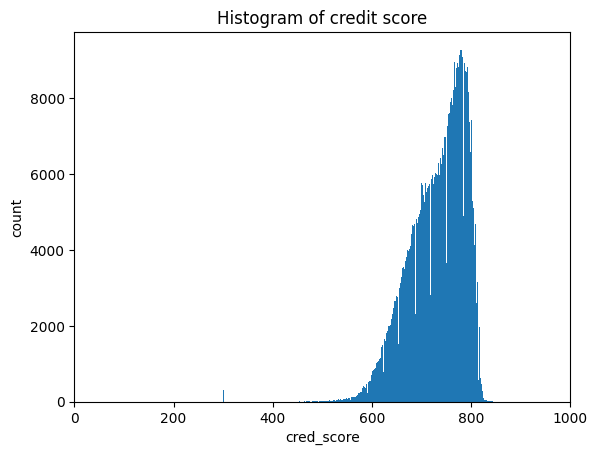

In [8]:
#plotting histograms
plt.hist(og_df['cred_score'].dropna(), bins=5000)
plt.xlabel('cred_score')
plt.ylabel('count')
plt.xlim(0,1000)
plt.title('Histogram of credit score')
plt.show()

C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\1320943883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\1320943883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\1320943883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\1320943883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

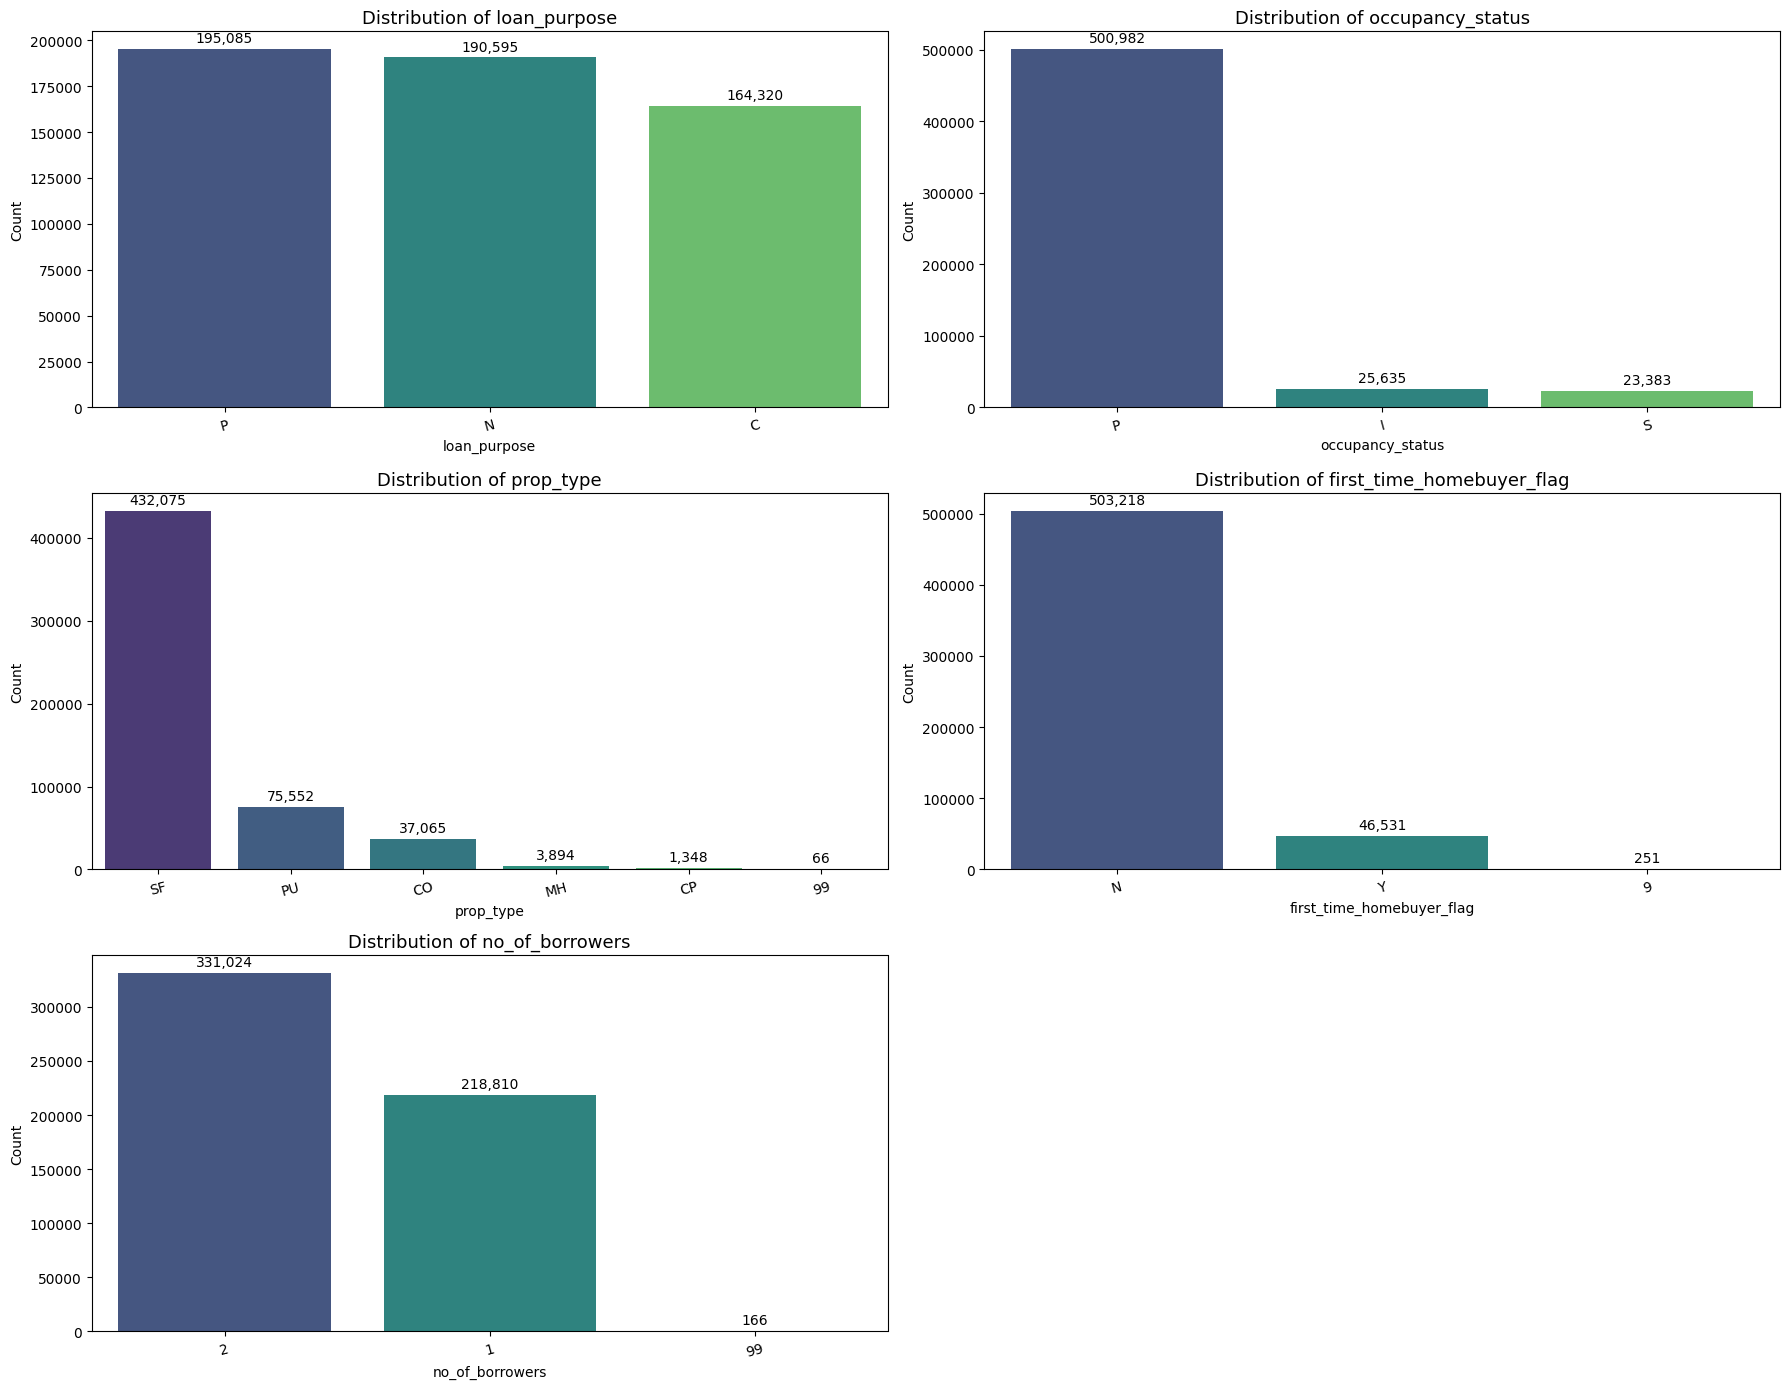

In [9]:
#categorical features
cat_vars = [
    "loan_purpose", 
    "occupancy_status", 
    "prop_type", 
    "first_time_homebuyer_flag", 
    "no_of_borrowers"
]
plt.figure(figsize=(18, 14))

for i, var in enumerate(cat_vars, start=1):
    plt.subplot(3, 2, i)
    
    # filtering non-nulls and plot counts sorted by frequency
    clean_data = og_df[og_df[var].notna()]
    sns.countplot(
        data=clean_data, 
        x=var, 
        order=clean_data[var].value_counts().index, 
        palette="viridis"
    )
    
    # adding textual counts on top of each bar
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
        
    plt.title(f"Distribution of {var}", fontsize=13)
    plt.xticks(rotation=15)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

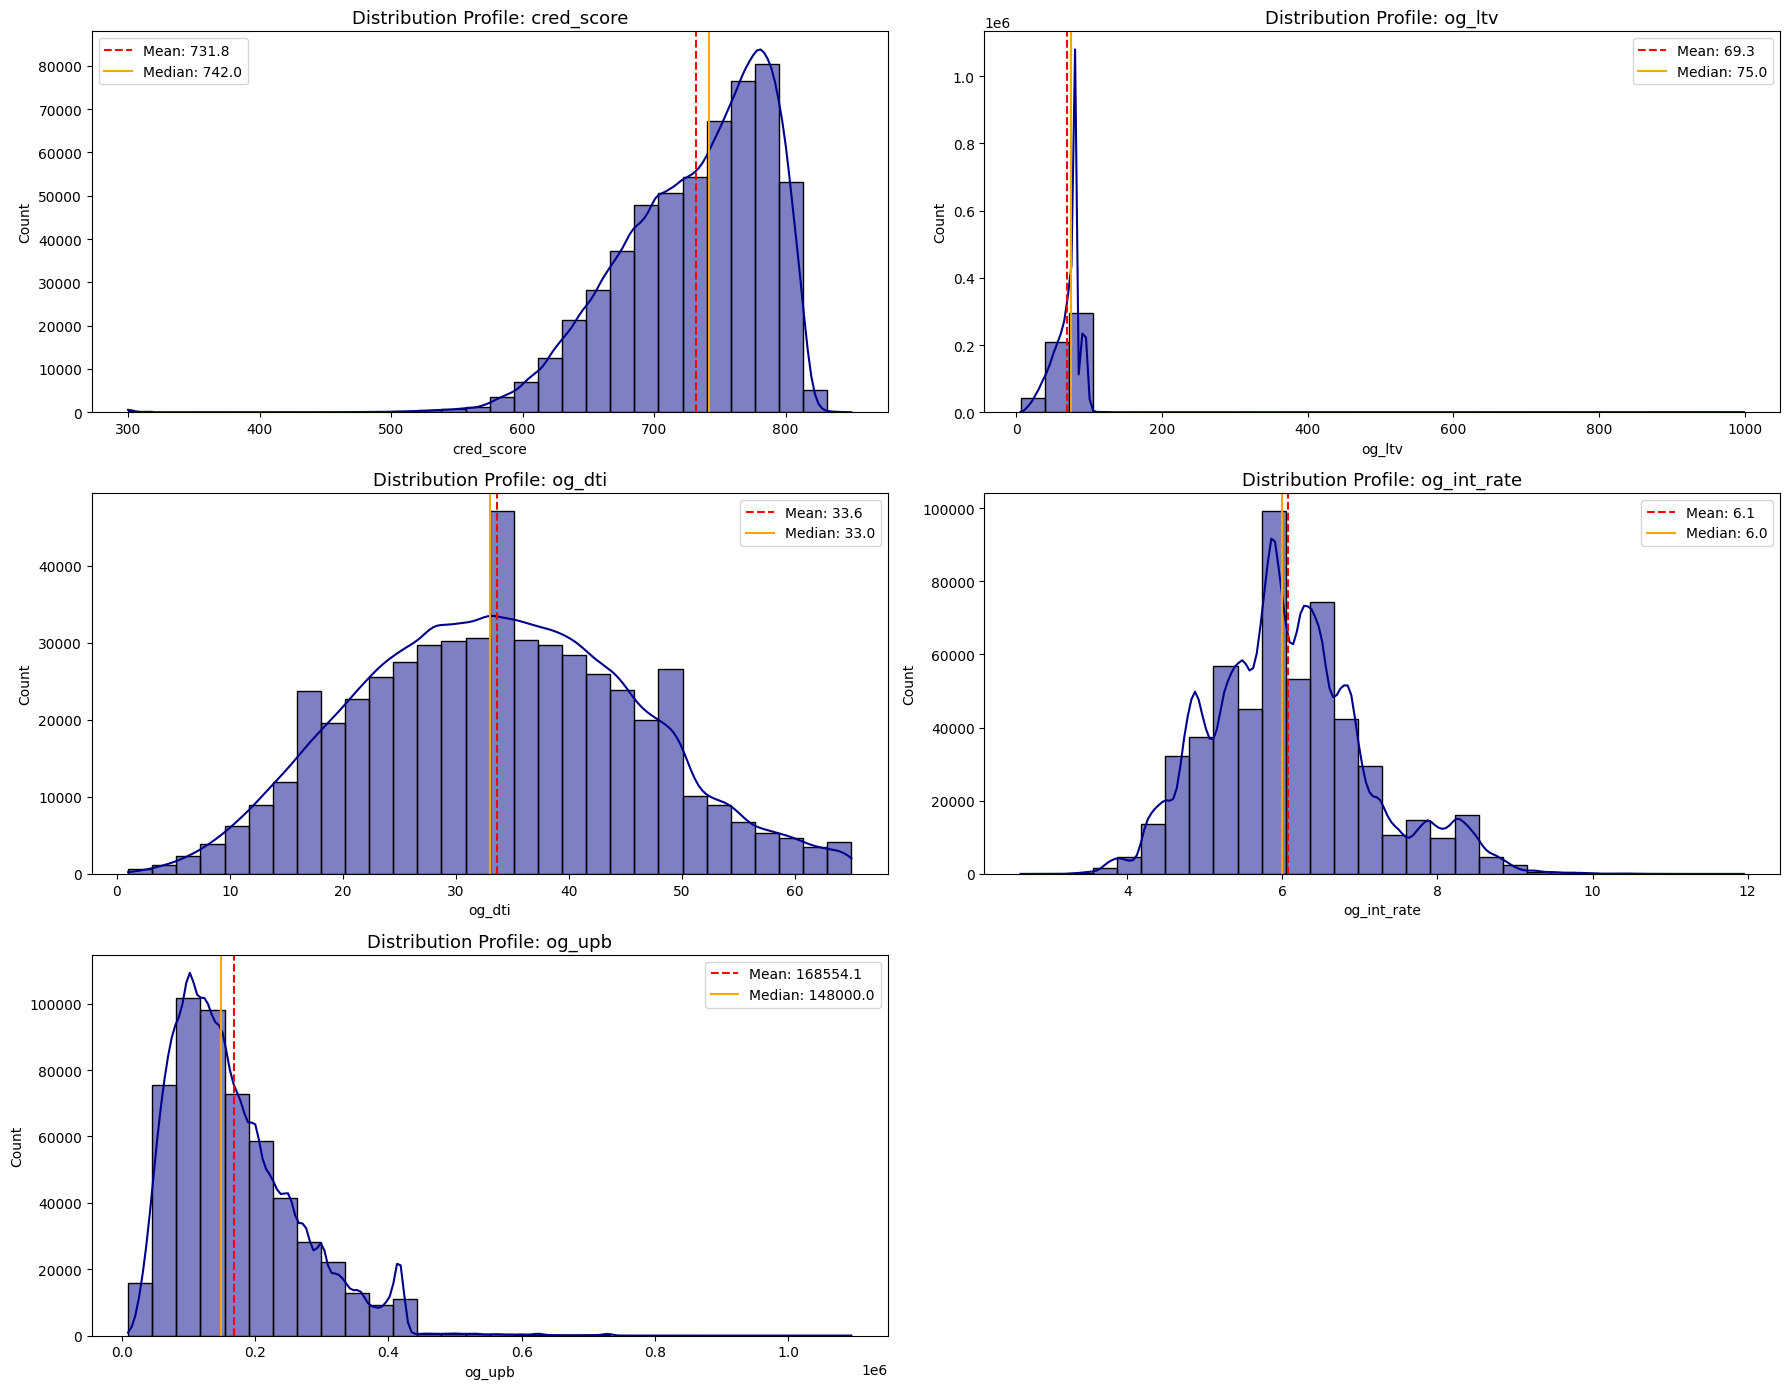

In [10]:
#continuous numeric features
num_vars = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb"]

plt.figure(figsize=(18, 14))

for i, var in enumerate(num_vars, start=1):
    plt.subplot(3, 2, i)
    
    # cleaning anomalies before plotting the distribution
    if var == "cred_score":
        plot_df = og_df[(og_df[var].notna()) & (og_df[var] <= 850)] # Cap at valid FICO Max
    elif var == "og_dti":
        plot_df = og_df[(og_df[var].notna()) & (og_df[var] < 999)]   # Striping out missing indicator
    else:
        plot_df = og_df[og_df[var].notna()]
        
    # Plotting data with Kernel Density Estimate (KDE) curve line
    sns.histplot(data=plot_df, x=var, bins=30, kde=True, color="darkblue")
    
    # mean and median of the dist in the plot
    mean_val = plot_df[var].mean()
    median_val = plot_df[var].median()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    plt.axvline(median_val, color='orange', linestyle='-', label=f'Median: {median_val:.1f}')
    
    plt.title(f"Distribution Profile: {var}", fontsize=13)
    plt.legend()

plt.tight_layout()
plt.show()

C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\3558775597.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


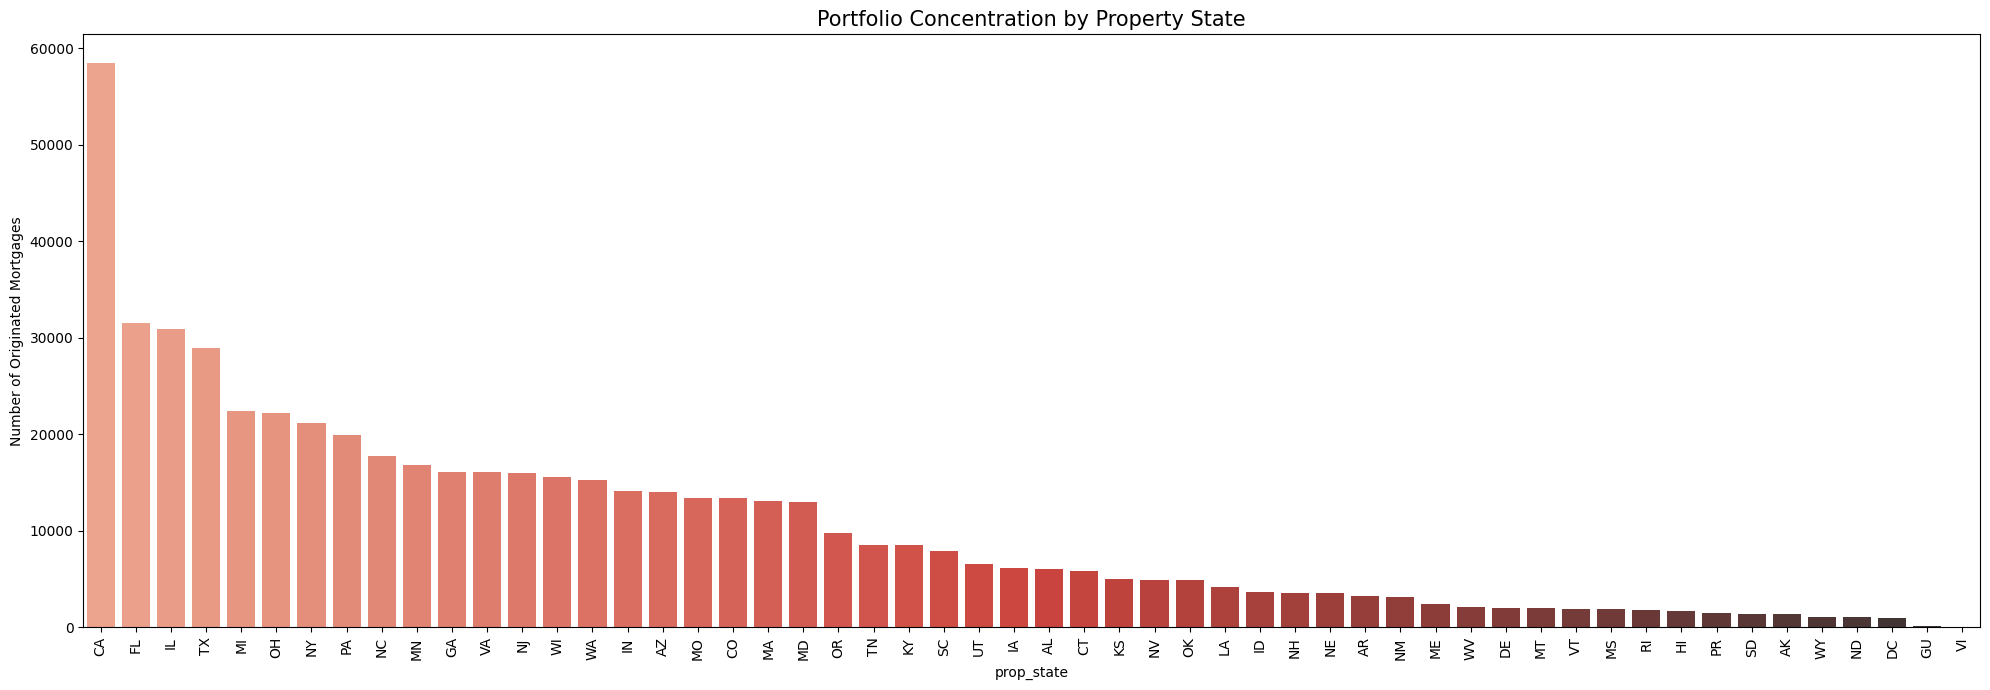

In [11]:
# state concetration plot
plt.figure(figsize=(20, 7))

state_data = og_df[og_df["prop_state"].notna()]
sns.countplot(
    data=state_data, 
    x="prop_state", 
    order=state_data["prop_state"].value_counts().index, 
    palette="Reds_d"
)

plt.title("Portfolio Concentration by Property State", fontsize=15)
plt.xticks(rotation=90, fontsize=10) 
plt.ylabel("Number of Originated Mortgages")
plt.tight_layout()
plt.show()

we check default rate vs credit score

In [12]:
def analyze_credit_score_vs_default(orig_df, perf_df): 
    # Drop rows where credit score is missing or placeholder (Freddie Mac uses 9999)
    analysis_df = og_df[
        (og_df["cred_score"].notna()) & 
        (og_df["cred_score"] != 9999)
    ][["loan_seq_no", "cred_score", "is_default"]].copy()
    
    
    # Credit Score Bins
    bins = [0, 579, 669, 739, 799, 850]
    labels = ["Poor (300-579)", "Fair (580-669)", "Good (670-739)", "Very Good (740-799)", "Exceptional (800-850)"]
    
    analysis_df["credit_score_tier"] = pd.cut(
        analysis_df["cred_score"], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
        )
    summary = analysis_df.groupby("credit_score_tier", observed=False).agg(
        total_loans=("is_default", "count"),
        total_defaults=("is_default", "sum")
    ).reset_index()
    
    # Calculate the Default Rate percentage
    summary["default_rate_pct"] = (summary["total_defaults"] / summary["total_loans"]) * 100
    
    # Calculate portfolio share for extra context
    summary["portfolio_share_pct"] = (summary["total_loans"] / summary["total_loans"].sum()) * 100
    
    return summary

credit_risk_profile = analyze_credit_score_vs_default(og_df, m_df)

print(credit_risk_profile.to_string(index=False))

    credit_score_tier  total_loans  total_defaults  default_rate_pct  portfolio_share_pct
       Poor (300-579)         3611             842         23.317641             0.658454
       Fair (580-669)        77895           14367         18.444059            14.203893
       Good (670-739)       184573           16222          8.788934            33.656269
  Very Good (740-799)       242654            7202          2.968012            44.247145
Exceptional (800-850)        39673             698          1.759383             7.234239


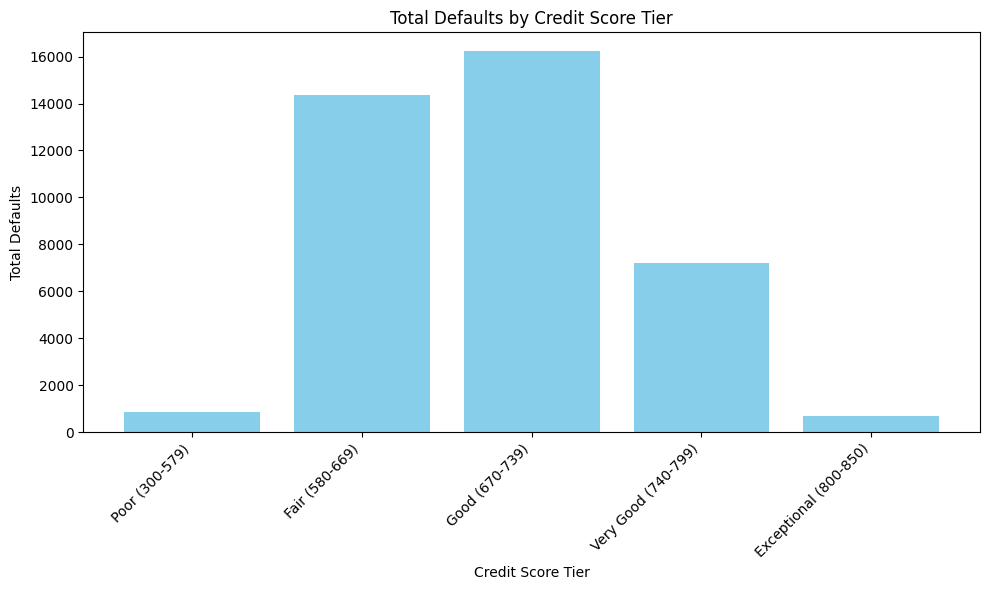

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(credit_risk_profile['credit_score_tier'], credit_risk_profile['total_defaults'], color='skyblue')
plt.xlabel('Credit Score Tier')
plt.ylabel('Total Defaults')
plt.title('Total Defaults by Credit Score Tier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# Keeping valid FICO records
clean_fico_df = og_df[(og_df["cred_score"].notna()) & (og_df["cred_score"] <= 850)].copy()

# Slicing into 10 equal-count deciles
clean_fico_df["fico_decile"] = pd.qcut(clean_fico_df["cred_score"], q=10, labels=False) + 1

decile_summary = clean_fico_df.groupby("fico_decile").agg(
    min_score=("cred_score", "min"),
    max_score=("cred_score", "max"),
    total_loans=("is_default", "count"),
    total_defaults=("is_default", "sum")
).reset_index()

decile_summary["default_rate_pct"] = (decile_summary["total_defaults"] / decile_summary["total_loans"]) * 100
decile_summary["portfolio_share_pct"] = (decile_summary["total_loans"] / decile_summary["total_loans"].sum()) * 100

print("\n" + " "*20 + " CREDIT SCORE DECILE RISK TABLE " + " "*20)
print(decile_summary.to_string(index=False, formatters={
    "total_loans": "{:,}".format, 
    "total_defaults": "{:,}".format, 
    "default_rate_pct": "{:.2f}%".format,
    "portfolio_share_pct": "{:.2f}%".format
}))


                     CREDIT SCORE DECILE RISK TABLE                     
 fico_decile  min_score  max_score total_loans total_defaults default_rate_pct portfolio_share_pct
           1        300        654      55,905         11,402           20.40%              10.19%
           2        655        683      54,981          7,585           13.80%              10.03%
           3        684        705      55,539          5,563           10.02%              10.13%
           4        706        724      53,960          4,170            7.73%               9.84%
           5        725        742      55,547          3,201            5.76%              10.13%
           6        743        757      53,596          2,388            4.46%               9.77%
           7        758        771      57,948          1,788            3.09%              10.57%
           8        772        783      54,484          1,309            2.40%               9.93%
           9        784        795 

This already shows us the proportion of credit score with which bankers have to be careful.

In [15]:
def num_vars_vs_default_independent(m_df, og_df):
    
    feature_cols = ["loan_seq_no", "og_ltv", "og_dti", "og_int_rate", "og_upb"]
    
    analysis_df = og_df[
        (og_df["og_ltv"].notna()) & (og_df["og_ltv"] > 0) &
        (og_df["og_dti"].notna()) & (og_df["og_dti"] > 0) &
        (og_df["og_int_rate"].notna()) & (og_df["og_int_rate"] > 0) &
        (og_df["og_upb"].notna()) & (og_df["og_upb"] > 0)
    ][feature_cols + ["is_default"]].copy()
    
    # Distinct Tier Bins
    analysis_df["LTV"] = pd.cut(analysis_df["og_ltv"], bins=[0, 30, 55, 70, 85, 100], include_lowest=True)
    analysis_df["DTI"] = pd.cut(analysis_df["og_dti"], bins=[0, 20, 40, 60, 80, 100], include_lowest=True)
    analysis_df["Interest Rate"] = pd.cut(analysis_df["og_int_rate"], bins=[0, 2, 4, 6, 8, 10], include_lowest=True)
    
    upb_bins = [0, 100000, 250000, 400000, 600000, 1000000] 
    analysis_df["UPB"] = pd.cut(analysis_df["og_upb"], bins=upb_bins, include_lowest=True)
    
    factors = ["LTV", "DTI", "Interest Rate", "UPB"]
    summary_slices = []
    
    for factor in factors:
        slice_df = analysis_df.groupby(factor, observed=False).agg(
            total_loans=("is_default", "count"),
            total_defaults=("is_default", "sum")
        ).reset_index()
        
        slice_df = slice_df.rename(columns={factor: "risk_tier"})
        slice_df["risk_tier"] = slice_df["risk_tier"].astype(str)
        slice_df.insert(0, "factor", factor)
        summary_slices.append(slice_df)

    #stacking every variables data
    master_summary = pd.concat(summary_slices, ignore_index=True)
    master_summary["default_rate_pct"] = (master_summary["total_defaults"] / master_summary["total_loans"]) * 100
    
    return master_summary

independent_risk_profile = num_vars_vs_default_independent(m_df, og_df)

independent_risk_profile


,factor,risk_tier,total_loans,total_defaults,default_rate_pct
0,LTV,"(-0.001, 30.0]",19826,346,1.745183
1,LTV,"(30.0, 55.0]",97318,2935,3.015886
2,LTV,"(55.0, 70.0]",120072,6974,5.808182
3,LTV,"(70.0, 85.0]",239168,19053,7.966367
4,LTV,"(85.0, 100.0]",71878,9829,13.674560
5,DTI,"(-0.001, 20.0]",78240,2459,3.142894
6,DTI,"(20.0, 40.0]",287926,17705,6.149149
7,DTI,"(40.0, 60.0]",146222,15974,10.924485
8,DTI,"(60.0, 80.0]",7614,1122,14.736013
9,DTI,"(80.0, 100.0]",0,0,NaN


C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\2577959263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "LTV"],
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\2577959263.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "DTI"],
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\2577959263.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=independent_risk_profile[independent_risk_profile

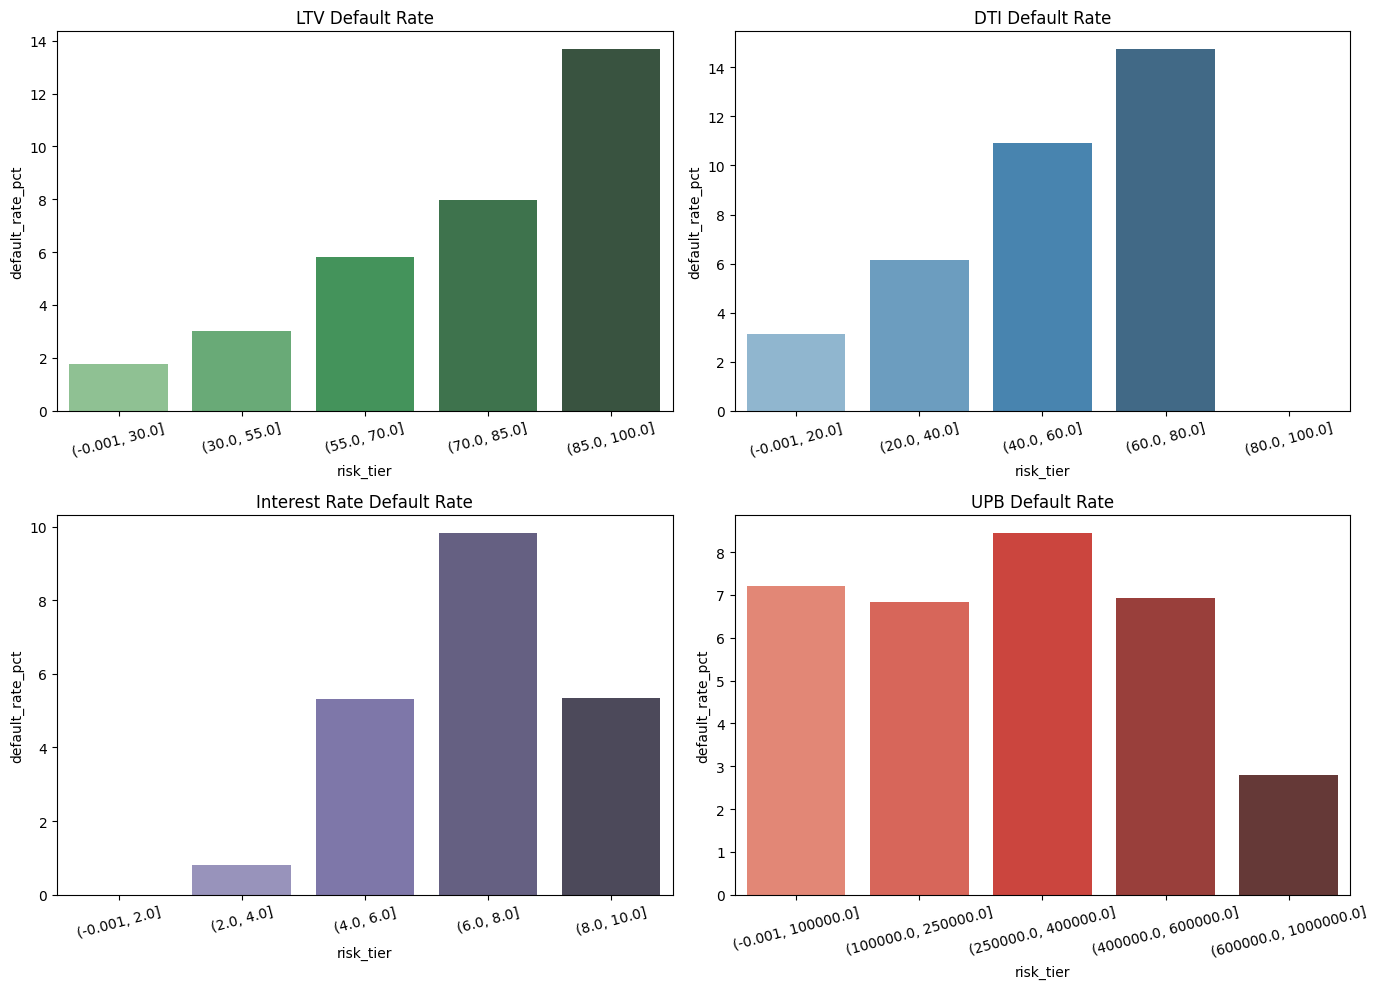

In [16]:
plt.figure(figsize=(14, 10))  

# Plot 1
plt.subplot(2, 2, 1)  
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "LTV"], 
            x="risk_tier", y="default_rate_pct", palette="Greens_d")
plt.title("LTV Default Rate")
plt.xticks(rotation=15)

#Plot 2
plt.subplot(2, 2, 2)  
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "DTI"], 
            x="risk_tier", y="default_rate_pct", palette="Blues_d")
plt.title("DTI Default Rate")
plt.xticks(rotation=15)

#Plot 3
plt.subplot(2, 2, 3) 
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "Interest Rate"], 
            x="risk_tier", y="default_rate_pct", palette="Purples_d") 
plt.title("Interest Rate Default Rate")
plt.xticks(rotation=15)

#Plot 4
plt.subplot(2, 2, 4)  
sns.barplot(data=independent_risk_profile[independent_risk_profile["factor"] == "UPB"], 
            x="risk_tier", y="default_rate_pct", palette="Reds_d") 
plt.title("UPB Default Rate")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [17]:
print(m_df.columns)
print(og_df.columns)

Index(['loan_seq_no', 'monthly_reporting_period', 'current_actual_upb',
       'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'defect_settlement_date',
       'modification_flag', 'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_non_interest_bearing_upb', 'ddlpi',
       'mi_recoveries', 'net_sale_proceeds', 'non_mi_recoveries',
       'total_expenses', 'legal_costs', 'maintenance_and_preservation_costs',
       'taxes_and_insurance', 'miscellaneous_expenses',
       'actual_loss_calculation', 'cumulative_modification_cost',
       'interest_rate_step_indicator', 'payment_deferral_flag', 'eltv',
       'zero_balance_removal_upb', 'delinquent_accrued_interest',
       'delinquency_due_to_disaster', 'borrower_assistance_status_code',
       'current_month_modification_cost', 'interest_bearing_upb',
       'mortgage_insurance_cancel_flag', 'servicer_name',
       'bankruptcy_cramdown_cost', 'originati

Now we go to look for property's relation with Default rate

In [18]:
def categorical_vars_vs_default(m_df, og_df):
    
    #5 target categorical features
    factors = [
        "loan_purpose",
        "no_of_borrowers",
        "first_time_homebuyer_flag",
        "occupancy_status",
        "prop_type"
    ]
    
    feature_cols = ["loan_seq_no"] + factors + ["is_default"]
    
    # Dropping rows where ANY of these 5 columns are missing/NaN
    analysis_df = og_df.dropna(subset=factors)[feature_cols].copy()
    
    summary_slices = []
    
    for factor in factors:
  
        slice_df = analysis_df.groupby(factor, observed=False).agg(
            total_loans=("is_default", "count"),
            total_defaults=("is_default", "sum")
        ).reset_index()
        
        # Renaming the column category name to a unified column name for stacking
        slice_df = slice_df.rename(columns={factor: "risk_category"})
        slice_df["risk_category"] = slice_df["risk_category"].astype(str)
        
        # Injecting metadata column at position 0 to track the originating factor
        slice_df.insert(0, "factor", factor)
        
        summary_slices.append(slice_df)
        
    master_summary = pd.concat(summary_slices, ignore_index=True)
    
    master_summary["default_rate_pct"] = (master_summary["total_defaults"] / master_summary["total_loans"]) * 100
    master_summary["portfolio_share_pct"] = (master_summary["total_loans"] / len(analysis_df)) * 100
    
    master_summary = master_summary.sort_values(by=["factor", "default_rate_pct"], ascending=[True, False]).reset_index(drop=True)
    
    return master_summary

categorical_risk_profile = categorical_vars_vs_default(m_df, og_df)
categorical_risk_profile



,factor,risk_category,total_loans,total_defaults,default_rate_pct,portfolio_share_pct
0,first_time_homebuyer_flag,Y,46531,4061,8.727515,8.460182
1,first_time_homebuyer_flag,N,503218,35349,7.024590,91.494182
2,first_time_homebuyer_flag,9,251,7,2.788845,0.045636
3,loan_purpose,C,164320,15303,9.312926,29.876364
4,loan_purpose,P,195085,13257,6.795499,35.470000
5,loan_purpose,N,190595,10857,5.696372,34.653636
6,no_of_borrowers,1,218810,22922,10.475755,39.783636
7,no_of_borrowers,2,331024,16491,4.981814,60.186182
8,no_of_borrowers,99,166,4,2.409639,0.030182
9,occupancy_status,I,25635,2393,9.334894,4.660909


In [19]:
# Calculate state_risk_profile for prop_state
factor = "prop_state"
feature_cols = ["is_default", factor]

analysis_df_state = og_df.dropna(subset=[factor])[feature_cols].copy()

state_risk_profile = analysis_df_state.groupby(factor, observed=False).agg(
    total_loans=("is_default", "count"),
    total_defaults=("is_default", "sum")
).reset_index()

state_risk_profile = state_risk_profile.rename(columns={factor: "risk_category"})
state_risk_profile["risk_category"] = state_risk_profile["risk_category"].astype(str)
state_risk_profile.insert(0, "factor", factor)
state_risk_profile["default_rate_pct"] = (state_risk_profile["total_defaults"] / state_risk_profile["total_loans"]) * 100

# Sorting by default rate for better visualization
state_risk_profile = state_risk_profile.sort_values(by="default_rate_pct", ascending=False).reset_index(drop=True)

C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\28459291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "loan_purpose"],
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\28459291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "no_of_borrowers"],
C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\28459291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorical_risk_profile[categoric

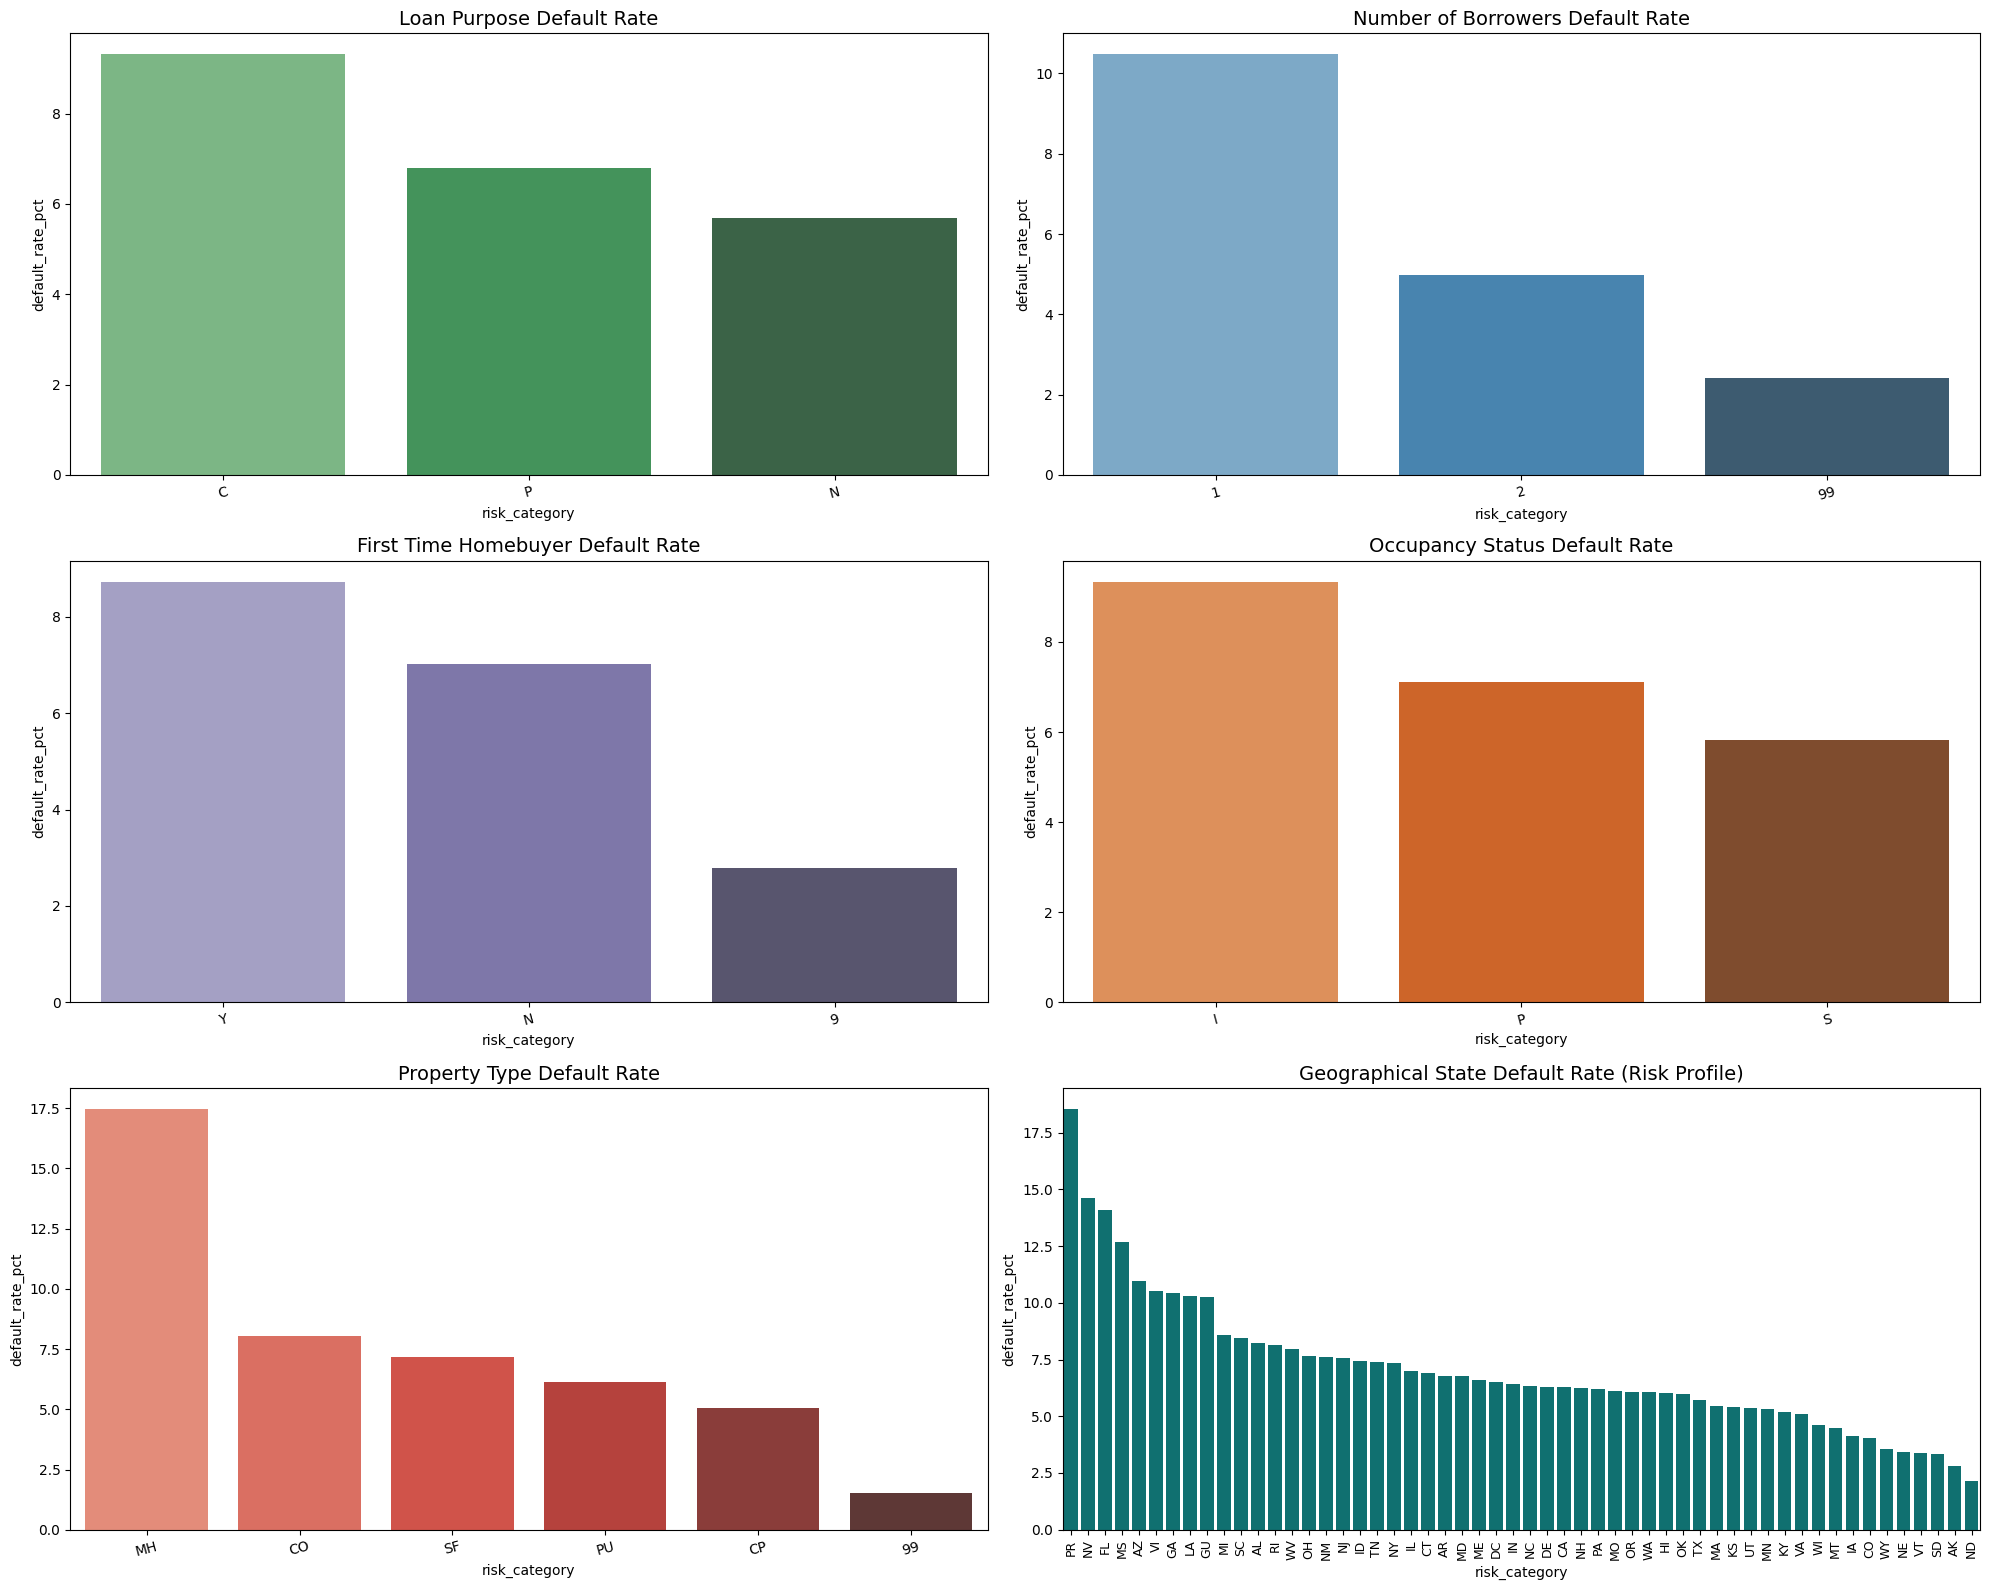

In [20]:
plt.figure(figsize=(20, 16))  

plt.subplot(3, 2, 1)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "loan_purpose"], 
            x="risk_category", y="default_rate_pct", palette="Greens_d")
plt.title("Loan Purpose Default Rate", fontsize=14)
plt.xticks(rotation=15)

plt.subplot(3, 2, 2)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "no_of_borrowers"], 
            x="risk_category", y="default_rate_pct", palette="Blues_d")
plt.title("Number of Borrowers Default Rate", fontsize=14)
plt.xticks(rotation=15)

plt.subplot(3, 2, 3)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "first_time_homebuyer_flag"], 
            x="risk_category", y="default_rate_pct", palette="Purples_d")
plt.title("First Time Homebuyer Default Rate", fontsize=14)
plt.xticks(rotation=15)

plt.subplot(3, 2, 4)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "occupancy_status"], 
            x="risk_category", y="default_rate_pct", palette="Oranges_d")
plt.title("Occupancy Status Default Rate", fontsize=14)
plt.xticks(rotation=15)

plt.subplot(3, 2, 5)  
sns.barplot(data=categorical_risk_profile[categorical_risk_profile["factor"] == "prop_type"], 
            x="risk_category", y="default_rate_pct", palette="Reds_d")
plt.title("Property Type Default Rate", fontsize=14)
plt.xticks(rotation=15)


plt.subplot(3, 2, 6)  
sns.barplot(data=state_risk_profile,
            x="risk_category", y="default_rate_pct", color="teal")
plt.title("Geographical State Default Rate (Risk Profile)", fontsize=14)
plt.xticks(rotation=90, fontsize=9) 

plt.tight_layout()
plt.show()

In [21]:
for c in cat_vars:
    ct = pd.crosstab(og_df[c], og_df["is_default"], margins=True, normalize="index") * 100
    ct.columns = ["Healthy_%", "Default_%"][:ct.shape[1]]      # 0 -> Healthy, 1 -> Default
    support = og_df[c].value_counts()                            # add the raw counts back
    ct["loans"] = ct.index.map(support).fillna(len(og_df)).astype(int)
    print("\n" + " "*15 + f" {c} " + " "*15)
    print(ct.round(2).to_string())


                loan_purpose                
              Healthy_%  Default_%   loans
loan_purpose                              
C                 90.69       9.31  164320
N                 94.30       5.70  190595
P                 93.20       6.80  195085
All               92.83       7.17  550000

                occupancy_status                
                  Healthy_%  Default_%   loans
occupancy_status                              
I                     90.67       9.33   25635
P                     92.88       7.12  500982
S                     94.18       5.82   23383
All                   92.83       7.17  550000

                prop_type                
           Healthy_%  Default_%   loans
prop_type                              
99             98.48       1.52      66
CO             91.98       8.02   37065
CP             94.96       5.04    1348
MH             82.54      17.46    3894
PU             93.88       6.12   75552
SF             92.81       7.19  432075
A

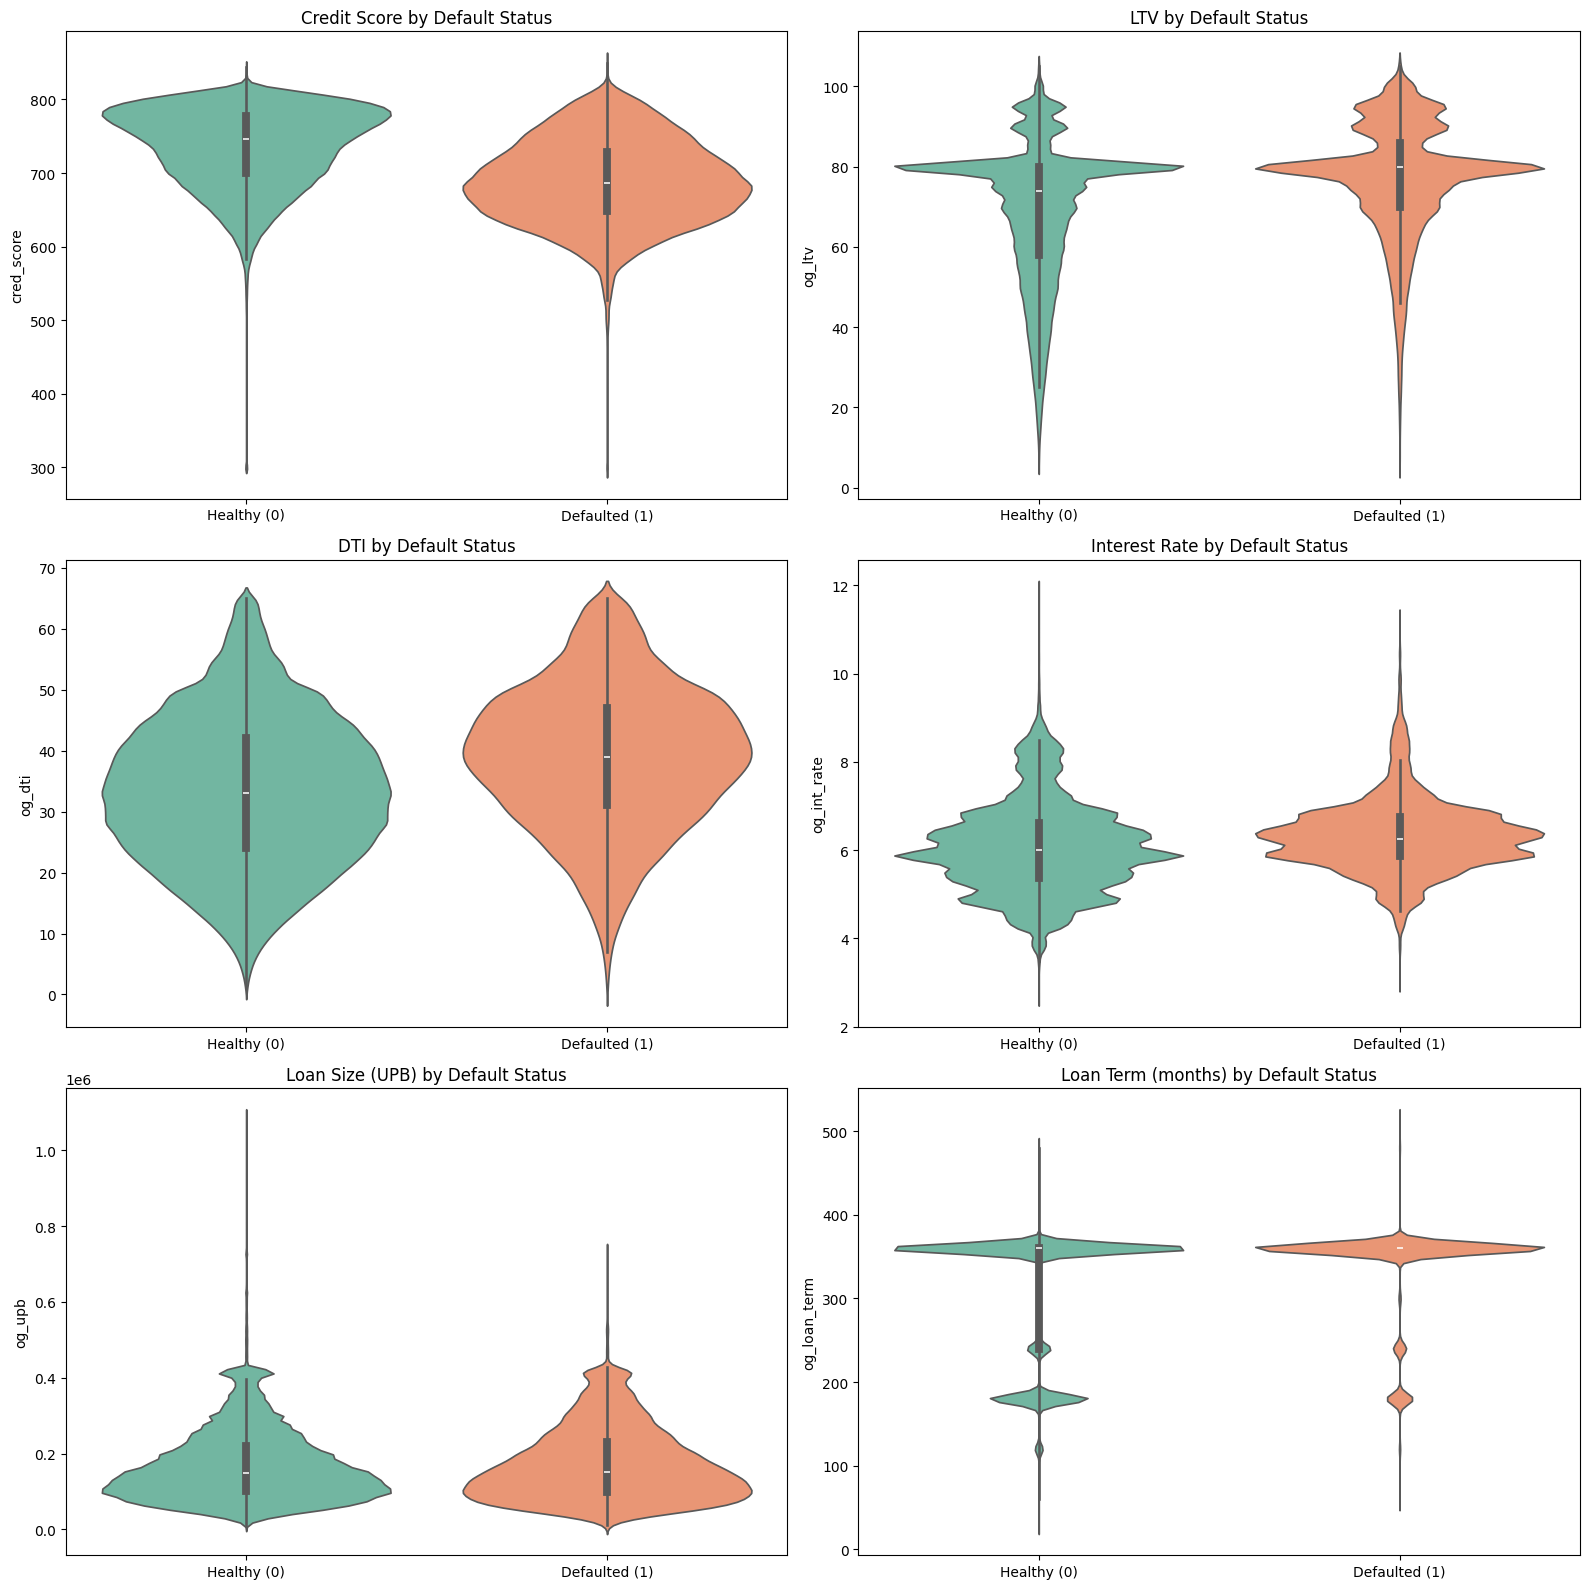

In [22]:
plots = [
    ("cred_score",   "Credit Score",  og_df["cred_score"] <= 850),
    ("og_ltv",       "LTV",           og_df["og_ltv"] <= 105),
    ("og_dti",       "DTI",           og_df["og_dti"] < 999),
    ("og_int_rate",  "Interest Rate", og_df["og_int_rate"] > 0),
    ("og_upb",       "Loan Size (UPB)", og_df["og_upb"] > 0),
    ("og_loan_term", "Loan Term (months)", og_df["og_loan_term"] > 0),
]

plt.figure(figsize=(16, 16))
for i, (col, label, mask) in enumerate(plots, start=1):
    plt.subplot(3, 2, i)
    sns.violinplot(data=og_df[mask], x="is_default", y=col, hue="is_default",
                   palette="Set2", legend=False)
    plt.title(f"{label} by Default Status")
    plt.xticks([0, 1], ["Healthy (0)", "Defaulted (1)"])
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [23]:
m_df

,loan_seq_no,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_legal_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,delinquent_accrued_interest,delinquency_due_to_disaster,borrower_assistance_status_code,current_month_modification_cost,interest_bearing_upb,mortgage_insurance_cancel_flag,servicer_name,bankruptcy_cramdown_cost,origination_year,bad_month
0,F00Q10000035,200210,101000.00,00,0,329.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,101000.00,7,OTHER,NaN,2000,False
1,F00Q10000035,200211,101000.00,00,1,328.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,101000.00,7,OTHER,NaN,2000,False
2,F00Q10000035,200212,101000.00,00,2,327.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,101000.00,7,OTHER,NaN,2000,False
3,F00Q10000035,200301,101000.00,00,3,326.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,101000.00,7,OTHER,NaN,2000,False
4,F00Q10000035,200302,100000.00,00,4,325.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,100000.00,7,OTHER,NaN,2000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33135521,F10Q40595389,202002,83674.02,0,102,258.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,83674.02,7,TRUIST BANK,NaN,2010,False
33135522,F10Q40595389,202003,83481.11,0,103,257.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,83481.11,7,TRUIST BANK,NaN,2010,False
33135523,F10Q40595389,202004,83287.47,0,104,256.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,83287.47,7,TRUIST BANK,NaN,2010,False
33135524,F10Q40595389,202005,83093.11,0,105,255.0,NaN,N,<NA>,NaN,...,NaN,NaN,NaN,NaN,83093.11,7,TRUIST BANK,NaN,2010,False


In [24]:
m_df.current_loan_delinquency_status.nunique()

111

     WORST-EVER DELINQUENCY PER LOAN     
                                  Loans  Share_%
current_loan_delinquency_status                 
Never late                       456624    83.02
30 DPD                            41836     7.61
60 DPD                            12123     2.20
90-179 DPD                        10476     1.90
180+ DPD                          28941     5.26


C:\Users\Manya\AppData\Local\Temp\ipykernel_16276\274882604.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=prof_pct.values, palette="magma")


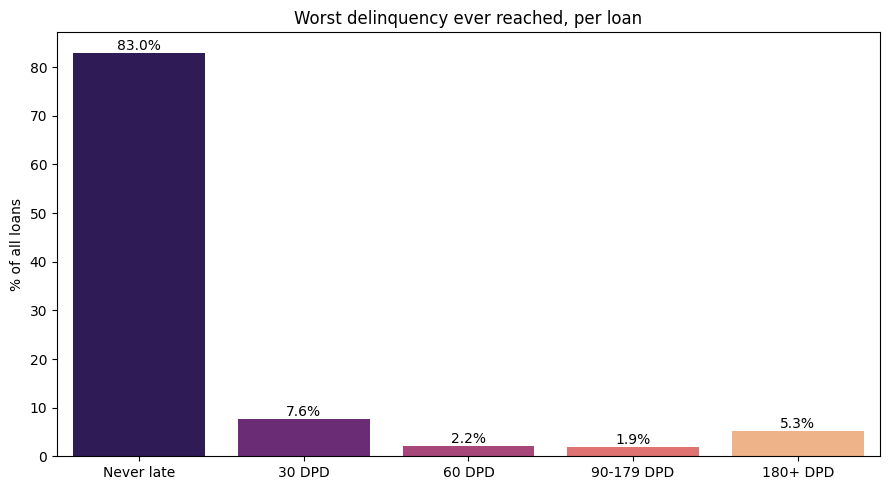

In [25]:
# Worst delinquency each loan EVER reached
dpd = pd.to_numeric(m_df["current_loan_delinquency_status"], errors="coerce")  # "RA" -> NaN, excluded
worst = dpd.groupby(m_df["loan_seq_no"]).max()

def bucket(v):
    if v == 0:  return "Never late"
    if v == 1:  return "30 DPD"
    if v == 2:  return "60 DPD"
    if v <= 5:  return "90-179 DPD"
    return "180+ DPD"

order = ["Never late", "30 DPD", "60 DPD", "90-179 DPD", "180+ DPD"]
prof = worst.map(bucket).value_counts().reindex(order)
prof_pct = (prof / prof.sum() * 100).round(2)

print("     WORST-EVER DELINQUENCY PER LOAN     ")
print(pd.DataFrame({"Loans": prof, "Share_%": prof_pct}).to_string())

plt.figure(figsize=(9, 5))
sns.barplot(x=order, y=prof_pct.values, palette="magma")
for i, v in enumerate(prof_pct.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.ylabel("% of all loans")
plt.title("Worst delinquency ever reached, per loan")
plt.tight_layout()
plt.show()

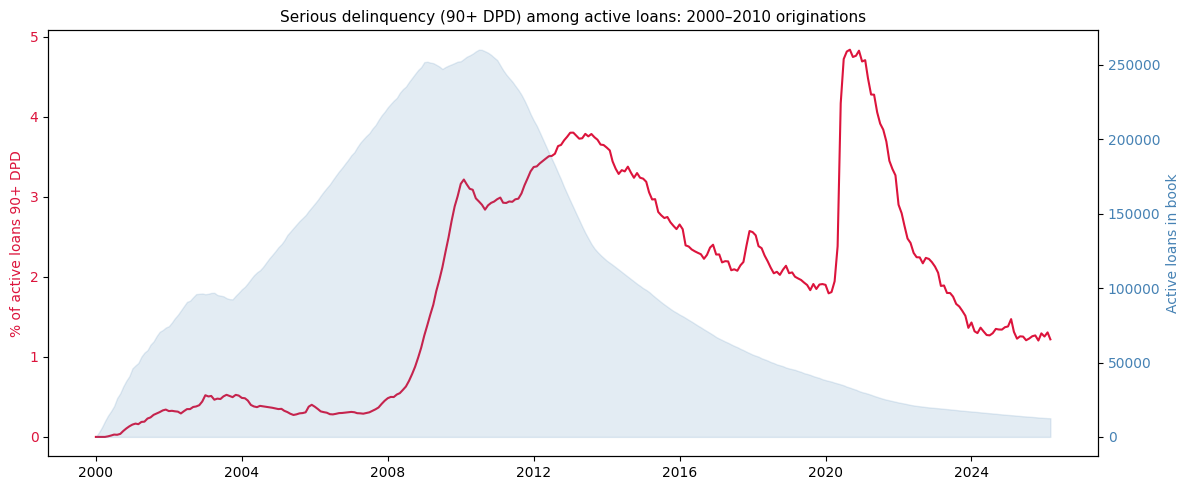

In [26]:
m = m_df[["monthly_reporting_period", "current_loan_delinquency_status"]].copy()
m["dpd"]  = pd.to_numeric(m["current_loan_delinquency_status"], errors="coerce")
m["is90"] = (m["dpd"] >= 3).astype(float)
m["date"] = pd.to_datetime(m["monthly_reporting_period"], format="%Y%m", errors="coerce")

rate   = m.groupby("date")["is90"].mean() * 100    # % of active loans 90+ DPD
active = m.groupby("date")["is90"].size()          # how many loans are active that month

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(rate.index, rate.values, color="crimson", label="90+ DPD rate")
ax1.set_ylabel("% of active loans 90+ DPD", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2 = ax1.twinx()
ax2.fill_between(active.index, active.values, color="steelblue", alpha=0.15)
ax2.set_ylabel("Active loans in book", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title("Serious delinquency (90+ DPD) among active loans: 2000–2010 originations", fontsize=11)
fig.tight_layout()
plt.show()

Corr Analysis

In [27]:
og_df.cred_score

0         790
1         771
2         762
3         737
4         594
         ... 
549995    808
549996    824
549997    785
549998    717
549999    791
Name: cred_score, Length: 550000, dtype: int64

In [28]:
num_vars_matrix = og_df[["cred_score",
"og_ltv",
"og_cltv",
"og_dti",
"og_upb",
"og_int_rate",
"og_loan_term"]].copy()

#remove the NaNs (eg. 9999, etc.)
num_vars_matrix["cred_score"] = num_vars_matrix["cred_score"].where(num_vars_matrix["cred_score"] <= 850)
num_vars_matrix["og_dti"]     = num_vars_matrix["og_dti"].where(num_vars_matrix["og_dti"] < 999)
num_vars_matrix["og_ltv"]     = num_vars_matrix["og_ltv"].where(num_vars_matrix["og_ltv"] <= 105)
num_vars_matrix["og_cltv"]    = num_vars_matrix["og_cltv"].where(num_vars_matrix["og_cltv"] <= 200)

corr_matrix = num_vars_matrix.corr()
corr_matrix


,cred_score,og_ltv,og_cltv,og_dti,og_upb,og_int_rate,og_loan_term
cred_score,1.000000,-0.202340,-0.188901,-0.169774,0.081916,-0.278734,-0.079785
og_ltv,-0.202340,1.000000,0.959220,0.162016,0.094611,0.183204,0.287156
og_cltv,-0.188901,0.959220,1.000000,0.168191,0.123561,0.156551,0.295878
og_dti,-0.169774,0.162016,0.168191,1.000000,0.141856,0.086579,0.174820
og_upb,0.081916,0.094611,0.123561,0.141856,1.000000,-0.225784,0.221698
og_int_rate,-0.278734,0.183204,0.156551,0.086579,-0.225784,1.000000,0.265113
og_loan_term,-0.079785,0.287156,0.295878,0.174820,0.221698,0.265113,1.000000


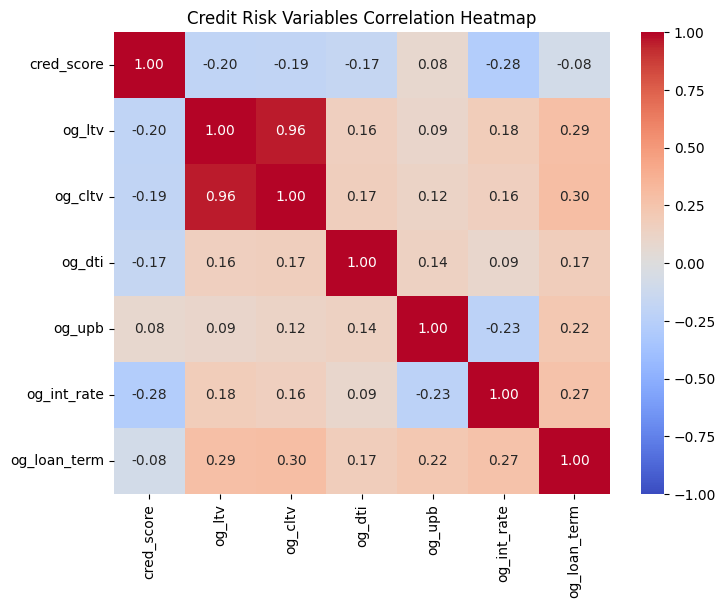

In [29]:
plt.figure(figsize=(8, 6))

# 'annot=True' prints the actual correlation numbers inside the colored boxes
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            vmin=-1, 
            vmax=1)

plt.title("Credit Risk Variables Correlation Heatmap")
plt.show()

In [30]:
vif_features = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb", "og_loan_term"]

# sentinels -> NaN, then drop incomplete rows
clean = og_df[vif_features].copy()
clean["cred_score"] = clean["cred_score"].where(clean["cred_score"] <= 850)
clean["og_dti"]     = clean["og_dti"].where(clean["og_dti"] < 999)
clean["og_ltv"]     = clean["og_ltv"].where(clean["og_ltv"] <= 105)
clean = clean.dropna()

X = add_constant(clean)   # intercept at index 0
vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif[vif["feature"] != "const"].round(2).to_string(index=False))

     feature  VIF
  cred_score 1.14
      og_ltv 1.15
      og_dti 1.08
 og_int_rate 1.28
      og_upb 1.18
og_loan_term 1.25


                            loan_purpose  occupancy_status  prop_type  first_time_homebuyer_flag  channel  ppm_flag  prop_state  relief_refinance_indicator  super_conforming_flag
loan_purpose                        1.00              0.09       0.13                       0.29     0.09      0.03        0.14                        0.27                   0.04
occupancy_status                    0.09              1.00       0.10                       0.07     0.02      0.01        0.11                        0.02                   0.01
prop_type                           0.13              0.10       1.00                       0.07     0.05      0.02        0.19                        0.02                   0.02
first_time_homebuyer_flag           0.29              0.07       0.07                       1.00     0.02      0.01        0.06                        0.06                   0.00
channel                             0.09              0.02       0.05                       0.02     1.00

<Axes: >

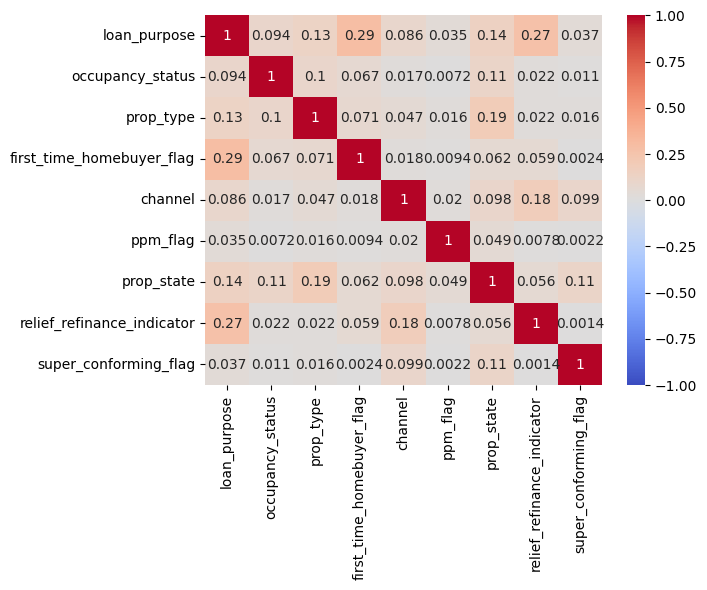

In [31]:
# Cramer'V calculation for categorical variables
cat_vars = ["loan_purpose", "occupancy_status", "prop_type", "first_time_homebuyer_flag",
       "channel", "ppm_flag", "prop_state",
       "relief_refinance_indicator", "super_conforming_flag"]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    # bias correction (Bergsma) so large tables don't inflate the score
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

cv = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for a in cat_vars:
    for b in cat_vars:
        cv.loc[a, b] = 1.0 if a == b else cramers_v(og_df[a], og_df[b])

print(cv.round(2).to_string())

sns.heatmap(cv.astype(float), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [32]:
og_clean = og_df.copy()

NUM = ["cred_score", "og_ltv", "og_cltv", "og_dti", "og_int_rate", "og_upb",
       "og_loan_term", "mortgage_insurance_percent", "unit_no", "no_of_borrowers"]
CAT = ["loan_purpose", "occupancy_status", "prop_type", "first_time_homebuyer_flag",
       "channel", "ppm_flag", "prop_state", "seller_name",
       "relief_refinance_indicator", "super_conforming_flag"]

for col, thr in [("cred_score", 850), ("og_ltv", 105), ("og_cltv", 200)]:
    og_clean[col] = og_clean[col].where(og_clean[col] <= thr)
for col, thr in [("og_dti", 999), ("mortgage_insurance_percent", 999),
                 ("unit_no", 90), ("no_of_borrowers", 90)]:
    og_clean[col] = og_clean[col].where(og_clean[col] < thr)

CAT_SENTINELS = {"first_time_homebuyer_flag": ["9"], "channel": ["9"],
                 "prop_type": ["99"], "metro_code_msa": ["Unknown"]}

for col, sents in CAT_SENTINELS.items():
    og_clean[col] = og_clean[col].replace(sents, "Missing")

In [33]:
print("Skewness table for numerical features")
print(og_clean[NUM].skew().sort_values().round(3).to_string())

Skewness table for numerical features
og_loan_term                 -1.070
cred_score                   -0.889
og_ltv                       -0.816
og_cltv                      -0.685
no_of_borrowers              -0.417
og_dti                        0.095
og_int_rate                   0.502
og_upb                        1.137
mortgage_insurance_percent    2.390
unit_no                       9.670


In [35]:
rows = []
for col in NUM:
    s = og_clean[col].dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr #lower and upper fence found using IQR
    iqr_out = int(((s < lo) | (s > hi)).sum())

    z = (s - s.mean()) / s.std()
    z_out = int((z.abs() > 3).sum())

    rows.append({
        "feature": col, "min": s.min(), "max": s.max(),
        "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
        "IQR_outliers": iqr_out, "IQR_%": round(iqr_out/len(s)*100, 2),
        "Z_outliers": z_out, "Z_%": round(z_out/len(s)*100, 2),
    })

out = pd.DataFrame(rows)
print(" "*40 + "Outlier detection table")
print(out.to_string(index=False))

                                        Outlier detection table
                   feature      min        max  lower_fence  upper_fence  IQR_outliers  IQR_%  Z_outliers  Z_%
                cred_score  300.000     850.00        572.0        900.0          2661   0.49        2152 0.39
                    og_ltv    6.000     105.00         27.5        111.5         14067   2.56        2424 0.44
                   og_cltv    6.000     193.00         30.0        110.0         18056   3.28        2081 0.38
                    og_dti    1.000      65.00         -0.5         67.5             0   0.00           0 0.00
               og_int_rate    2.625      11.95          3.5          8.5          8487   1.54        1710 0.31
                    og_upb 9000.000 1095000.00     -80000.0     400000.0         15270   2.78        2861 0.52
              og_loan_term   30.000     513.00         60.0        540.0             1   0.00          33 0.01
mortgage_insurance_percent    0.000      52.00  

In [36]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*a.std()**2 + (n2-1)*b.std()**2) / (n1+n2-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

rows = []
for f in NUM:
    h = og_clean.loc[og_clean.is_default == 0, f].dropna()
    d = og_clean.loc[og_clean.is_default == 1, f].dropna()
    _, u_p = stats.mannwhitneyu(h, d, alternative="two-sided")
    rows.append({"feature": f, "mean_healthy": round(h.mean(), 2),
                 "mean_default": round(d.mean(), 2),
                 "cohens_d": round(cohens_d(h, d), 3), "mannwhitney_p": u_p})

num_sig = pd.DataFrame(rows)
num_sig = num_sig.reindex(num_sig["cohens_d"].abs().sort_values(ascending=False).index)
print(num_sig.to_string(index=False))

                   feature  mean_healthy  mean_default  cohens_d  mannwhitney_p
                cred_score        735.21        688.01     0.869   0.000000e+00
                    og_ltv         68.56         76.94    -0.478   0.000000e+00
                   og_cltv         70.06         78.79    -0.478   0.000000e+00
                    og_dti         33.24         38.86    -0.466   0.000000e+00
mortgage_insurance_percent          3.13          6.82    -0.423   0.000000e+00
           no_of_borrowers          1.62          1.42     0.406   0.000000e+00
              og_loan_term        308.54        340.24    -0.403   0.000000e+00
               og_int_rate          6.06          6.32    -0.260   0.000000e+00
                   unit_no          1.03          1.04    -0.056   8.557605e-45
                    og_upb     168254.31     172438.03    -0.044   1.643705e-12


In [37]:
rows = []
for f in CAT:
    ct = pd.crosstab(og_clean[f], og_clean["is_default"])
    chi2, p, dof, _ = chi2_contingency(ct)
    rows.append({"feature": f, "levels": og_clean[f].nunique(),
                 "chi2": round(chi2, 1),
                 "cramers_v": round(cramers_v(og_clean[f], og_clean["is_default"]), 3),
                 "p": p})
print(pd.DataFrame(rows).sort_values("cramers_v", ascending=False).to_string(index=False))

                   feature  levels   chi2  cramers_v             p
               seller_name      42 8812.2      0.126  0.000000e+00
                prop_state      54 5211.8      0.097  0.000000e+00
                   channel       5 2993.5      0.074  0.000000e+00
              loan_purpose       3 1797.4      0.057  0.000000e+00
                 prop_type       6  799.0      0.038 1.863245e-170
          occupancy_status       3  246.2      0.021  3.482329e-54
 first_time_homebuyer_flag       3  192.9      0.019  1.303902e-42
     super_conforming_flag       2  105.8      0.014  8.259586e-25
                  ppm_flag       2    5.7      0.003  1.657429e-02
relief_refinance_indicator       2    6.9      0.003  8.526851e-03


In [38]:
# default rate by vintage (lifetime)
vintage_risk = og_df.groupby("origination_year")["is_default"].agg(
    Total_Loans="count", Total_Defaults="sum", Default_Rate_pct="mean")
vintage_risk["Default_Rate_pct"] = (vintage_risk["Default_Rate_pct"] * 100).round(2)
print("Vintage default rate (whole-life):\n", vintage_risk.to_string(), "\n")

# 90+ DPD deterioration by months-on-books
panel = pd.merge(
    m_df[["loan_seq_no", "monthly_reporting_period", "current_loan_delinquency_status"]],
    og_df[["loan_seq_no", "origination_year"]], on="loan_seq_no", how="inner")
panel["date"] = pd.to_datetime(panel["monthly_reporting_period"].astype(int).astype(str),
                               format="%Y%m")                       # the critical fix
panel["MOB"] = (panel["date"].dt.year - panel["origination_year"]) * 12 + (panel["date"].dt.month - 1)
panel = panel[(panel["MOB"] >= 0) & (panel["MOB"] <= 36)]
panel["is90"] = (pd.to_numeric(panel["current_loan_delinquency_status"], errors="coerce").fillna(0) >= 3).astype(int)

cohort = panel.pivot_table(index="origination_year", columns="MOB", values="is90", aggfunc="mean") * 100
mobs = [m for m in [0, 6, 12, 18, 24, 30, 36] if m in cohort.columns]
print("90+ DPD rate (%) by MOB:\n", cohort[mobs].round(2).to_string())

Vintage default rate (whole-life):
                   Total_Loans  Total_Defaults  Default_Rate_pct
origination_year                                               
2000                    50000            1746              3.49
2001                    50000            1616              3.23
2002                    50000            1699              3.40
2003                    50000            2033              4.07
2004                    50000            3548              7.10
2005                    50000            5500             11.00
2006                    50000            7164             14.33
2007                    50000            8242             16.48
2008                    50000            4657              9.31
2009                    50000            1591              3.18
2010                    50000            1621              3.24 

90+ DPD rate (%) by MOB:
 MOB                0     6     12    18    24    30    36
origination_year                              

In [39]:
def woe_iv(series, target, is_numeric, bins=10):
    df = pd.DataFrame({"x": series, "y": target}).dropna()
    df["bin"] = pd.qcut(df["x"], bins, duplicates="drop") if is_numeric else df["x"].astype(str)
    ct = pd.crosstab(df["bin"], df["y"]); ct.columns = ["Good", "Bad"]
    ct += 0.5                                   # smoothing, avoids log(0)
    ct["pg"] = ct["Good"] / ct["Good"].sum()
    ct["pb"] = ct["Bad"]  / ct["Bad"].sum()
    ct["woe"] = np.log(ct["pg"] / ct["pb"])
    ct["iv"]  = (ct["pg"] - ct["pb"]) * ct["woe"]
    return ct[["woe", "iv"]], ct["iv"].sum()

rows = []
for f in NUM: rows.append((f, "numeric",     woe_iv(og_clean[f], og_clean["is_default"], True)[1]))
for f in CAT: rows.append((f, "categorical", woe_iv(og_clean[f], og_clean["is_default"], False)[1]))
iv = pd.DataFrame(rows, columns=["Feature", "Type", "IV"]).sort_values("IV", ascending=False)

# mutual information on numerics (drop NaN, mark discrete cols)
sub = og_clean[NUM + ["is_default"]].dropna()
mi = mutual_info_classif(sub[NUM], sub["is_default"],
                         discrete_features=[f == "no_of_borrowers" for f in NUM],
                         random_state=42)
iv = iv.merge(pd.DataFrame({"Feature": NUM, "MI": mi}), on="Feature", how="left")

def band(v):
    return ("Drop <0.02" if v < 0.02 else "Weak" if v <= 0.1 else "Medium"
            if v <= 0.3 else "Strong" if v <= 0.5 else "Very strong (check leakage)")
iv["Band"] = iv["IV"].apply(band)
print(iv.round(4).to_string(index=False))

                   Feature        Type     IV     MI                        Band
                cred_score     numeric 0.7199 0.0240 Very strong (check leakage)
                    og_ltv     numeric 0.2744 0.0187                      Medium
               og_int_rate     numeric 0.2666 0.0129                      Medium
                   og_cltv     numeric 0.2655 0.0159                      Medium
               seller_name categorical 0.2302    NaN                      Medium
                    og_dti     numeric 0.2265 0.0093                      Medium
              og_loan_term     numeric 0.2051 0.0841                      Medium
                prop_state categorical 0.1235    NaN                      Medium
                   channel categorical 0.0816    NaN                        Weak
mortgage_insurance_percent     numeric 0.0641 0.0075                        Weak
              loan_purpose categorical 0.0474    NaN                        Weak
                 prop_type c